In [492]:
# statistical tests and plots to compare the values from 2 different time points
# load the correponding dataset by un-commenting the corresponding line

In [493]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro             # for normality testS
import statsmodels.api as sm                # for linear mixed-effects models (LMM)
import statsmodels.formula.api as smf       # for linear mixed-effects models (LMM)
from statsmodels.formula.api import mixedlm # for LMM
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

In [494]:
# Load shape measures, SELECTED
curRoot = 'C'  # 'C' or 'D'
# NOTE sca7, 3 and 2 relabeled use CS instead of CSSyl, only sca1 use CSSyl as before
curRegion = 'CS'  # CSSyl, CS or CSpreCS 
curSCA = 7      # !!! modify !!!
#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# separating time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# combining time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# combining time1 and time2, after relabelling, for CSpreCS. If CSSyl load RELABEL_REDO instead
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# combining time1 and time2, after relabelling and REDO for sca1
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'


# combining time1 and time2, after relabelling for sca7, sca3 and sca2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'

##########################################################################################################
# different sca
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

combined = pd.read_csv(curPath)
combined.index = combined['subjName']

##  Careful!! Time point of CERMOI 3 to 2
#combined.loc[combined['Time_point'] == 3, 'Time_point'] = 2

#####  Careful!! Here getting only the BIOSCA subjects!!!  #####
#combined = combined[combined['CodeICM'] == 'BIOSCA']

# for specific analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]
combined_only_ctl = combined[combined['SCA'] == 0]

combined_only_ctl_BIOSCA = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'BIOSCA')]
combined_only_ctl_CERMOI = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'CERMOI')]

combined_CAG = combined.dropna(subset=['CAG', 'Age_onset'])
#combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS', 'Age_onset'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS', 'Age_onset'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]


In [495]:
# For comparison of the same subject across time points, add a column 'ori_subjName' without the time point postfix

# add a column to combined_only_sca 'ori_subjName' without the postfix
# Remove the postfix in the form of '_something'

combined.loc[:,'ori_subjName'] = combined['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_BIOSCA.loc[:, 'ori_subjName'] = combined_only_ctl_BIOSCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_CERMOI.loc[:, 'ori_subjName'] = combined_only_ctl_CERMOI['subjName'].str.replace(r'_.+$', '', regex=True)

combined_CAG_only_SCA.loc[:, 'ori_subjName'] = combined_CAG_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_CCFS_only_SCA.loc[:, 'ori_subjName'] = combined_CCFS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_INAS_only_SCA.loc[:, 'ori_subjName'] = combined_INAS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
#print(combined_only_ctl)

C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\1243336850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\1243336850.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\1243336850.py

In [496]:
# Remove subjects with only one time point

def removeSingleTimePointReIndex(df):
  valid_subjects = df['ori_subjName'].value_counts()   # ensure each subject has two time points
  df = df[df['ori_subjName'].isin(valid_subjects[valid_subjects > 1].index)]
  df = df.sort_values(by=["ori_subjName", "Time_point"]).reset_index(drop=True)    
  return df

combined = removeSingleTimePointReIndex(combined)
combined_only_SCA = removeSingleTimePointReIndex(combined_only_SCA)
combined_CAG_only_SCA = removeSingleTimePointReIndex(combined_CAG_only_SCA)
combined_CCFS_only_SCA = removeSingleTimePointReIndex(combined_CCFS_only_SCA)
combined_INAS_only_SCA = removeSingleTimePointReIndex(combined_INAS_only_SCA)

In [497]:
#################  verifications of correlations, collinearity  #################
df = combined_CAG_only_SCA

# print correlation
#print(df[['Age', 'Age_onset']].corr())
#print(df[['CAG', 'SARA']].corr())
#print(df[['CAG', 'Age_onset']].corr())

#print(df['Age_onset'].isnull().sum())
#print(df[df['Age_onset'].isnull()])

print("Number of rows in DataFrame:", len(df))
print("DataFrame shape:", df.shape)
print("Unique subject names:", df['ori_subjName'].unique())
print("Rows with NaN in groups:", df[df["ori_subjName"].isnull()])

#print("Max index:", df.index.max())
#print("Unique subjects:", df["ori_subjName"].nunique())
#print("Rows per subject:", df["ori_subjName"].value_counts())
#print("Group labels shape:", df['ori_subjName'].shape)
#print("Group sizes:")
#print(df.groupby("ori_subjName").size())
#print("Row indices for each group:")
#print(groups)

Number of rows in DataFrame: 32
DataFrame shape: (32, 61)
Unique subject names: ['L001005DD' 'L001006DP' 'L001007DY' 'L001008JV' 'L001023DS' 'L001024DM'
 'L001031MA' 'L001088FP' 'flip-R001005DD' 'flip-R001006DP'
 'flip-R001007DY' 'flip-R001008JV' 'flip-R001023DS' 'flip-R001024DM'
 'flip-R001031MA' 'flip-R001088FP']
Rows with NaN in groups: Empty DataFrame
Columns: [subjName, label, surface_talairach, surface_native, maxdepth_talairach, maxdepth_native, meandepth_talairach, meandepth_native, hull_junction_length_talairach, hull_junction_length_native, GM_thickness, opening, Randomization, SCA, CAG, Sex, Age, SARA, INAS, Time_point, CodeICM, iso1, iso2, iso3, UMAP1_U1, UMAP1_U2, UMAP1_U3, UMAP2_U3, UMAP1_U4, UMAP2_U4, Age_onset, Group_ctl_pre_pat, Handedness, CCFS, Disease_duration, allele1, allele2, side, SCA_side, dominantSide, SCA_dominantSide, iso1_asy, iso2_asy, iso3_asy, UMAP1_U1_asy, UMAP1_U2_asy, UMAP1_U3_asy, UMAP2_U3_asy, UMAP1_U4_asy, UMAP2_U4_asy, surface_talairach_asy, surfa

In [498]:
df = combined
print(df['ori_subjName'].isna().sum())

print(df['ori_subjName'].unique()[:10])
print(df['ori_subjName'].dtype)


0
['L001005DD' 'L001006DP' 'L001007DY' 'L001008JV' 'L001009EL' 'L001010ED'
 'L001019DA' 'L001020HG' 'L001022LM' 'L001023DS']
object


In [499]:
################################    Perform LMM    ################################

def LMMTests(df,measures,x_var):   # df, measures are the dependant variables, x_var is the independant variables
    df = df.reset_index(drop=True)

    df.loc[:, 'SCA'] = df['SCA'].astype('category')       # Ensure 'SCA' is a categorical variable    
    results_dict = {}                                     # Initialize a dictionary to store results

    df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df['SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df['CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df['INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df['Age_centered'] = df['Age'] - df['Age'].mean()
    df['iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df['iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df['iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df['UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df['UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df['UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df['UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df['UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df['UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df['iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df['iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df['iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()       
    
    #####################  BY default, for SCA  ######################
    covariates = 'Age + C(side)'  
    covList = ['Age', 'side']   
    #covariates = 'C(CodeICM)'  
    #covList = ['CodeICM']       
    #covariates = 'C(CodeICM) + C(side)'  
    #covList = ['CodeICM', 'side']         
    #####################  BY default, for CAG/SARA/CCFS/INAS  ######################
    if not x_var.startswith('SCA'):
        covariates = 'Age_onset_centered + C(side)'  
        covList = ['Age_onset_centered', 'side']    
        ################################################   
        ##covariates = 'Age_centered + Age_onset_centered + C(side)'  
        ##covList = ['Age_centered', 'Age_onset_centered', 'side']    
        ################################################
        ##covariates = 'Age_onset_centered + C(Sex) + C(side)'  
        ##covList = ['Age_onset_centered', 'Sex', 'side']   

    df = df.dropna(subset=covList)
    
    for measure in measures:
        print(rf'###################################        {measure}        #####################################')     
        model_lmm = smf.mixedlm(measure + " ~ " + x_var + " + " + covariates,         
        #model_lmm = smf.mixedlm(measure+" ~ C(SCA) + Age + C(Sex) + C(Time_point)", 
                         data=df, 
                         groups=df["ori_subjName"],  # Random effect for each subject
                         #re_formula="~Age")  # Optional: Random slope for Age
                       )
        result = model_lmm.fit()
        print(result.summary())

###########################################################################################################################################
#curMeasures = [                                  # the dependant variables, 
#    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4','iso1_asy','iso2_asy','iso3_asy'
#]
#curMeasures = [                                  # the dependant variables, 
#    'iso1_centered', 'iso2_centered', 'iso3_centered', 'UMAP1_U1_centered', 'UMAP1_U2_centered', 
#    'UMAP1_U3_centered', 'UMAP2_U3_centered', 'UMAP1_U4_centered', 'UMAP2_U4_centered',
#    'iso1_asy_centered','iso2_asy_centered','iso3_asy_centered'
#]
curMeasures = [                                  # the dependant variables, 
    'iso1_centered', 'iso2_centered', 'iso3_centered', 'UMAP1_U1_centered', 'UMAP1_U2_centered', 
    'UMAP1_U3_centered', 'UMAP2_U3_centered', 'UMAP1_U4_centered', 'UMAP2_U4_centered'
]

# the independant variables
###cur_x_vars = ['SARA','CAG','CCFS','INAS'] 
cur_x_vars = ['SCA','SARA_centered','CAG_centered','CCFS_centered','INAS_centered'] 
#cur_x_vars = ['SCA']    
#cur_x_vars = ['Age_onset']  
#cur_x_vars = ['CAG'] 


# Run the function
for x_var in cur_x_vars:
    print(rf'###################################        {x_var}        #####################################')     
    #if x_var == 'SCA':
    if x_var.startswith('SCA'):        
        LMMTests(combined, curMeasures, x_var)        
    if x_var.startswith('SARA'):
        LMMTests(combined_only_SCA, curMeasures, x_var)
    if x_var.startswith('CAG'):
        LMMTests(combined_CAG_only_SCA, curMeasures, x_var) 
    if x_var.startswith('CCFS'):
        if len(combined_CCFS_only_SCA) > 0:
            LMMTests(combined_CCFS_only_SCA, curMeasures, x_var) 
        else:
            print('No CCFS info.')
    if x_var.startswith('INAS'):
        if len(combined_INAS_only_SCA) > 0:
            LMMTests(combined_INAS_only_SCA, curMeasures, x_var) 
        else:
            print('No INAS info.')
    if x_var == 'Age_onset':
        LMMTests(combined_CAG_only_SCA, curMeasures, x_var)         

###################################        SCA        #####################################
###################################        iso1_centered        #####################################
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: iso1_centered
No. Observations: 108     Method:             REML         
No. Groups:       54      Scale:              0.0440       
Min. group size:  2       Log-Likelihood:     -150.6491    
Max. group size:  2       Converged:          Yes          
Mean group size:  2.0                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.372    1.121  0.332 0.740 -1.824  2.569
C(side)[T.R]     -0.259    0.851 -0.305 0.761 -1.928  1.409
SCA              -0.036    0.126 -0.287 0.774 -0.283  0.211
Age              -0.003    0.018 -0.1

In [500]:
################  Below for testing the group difference  ####################
################  Use LMM instead of t-test               ####################

In [501]:
#########################  Test for group difference  #######################

combined_BIOSCA = combined[combined['CodeICM'] == 'BIOSCA']
#df = combined_BIOSCA  ####  testing BIOSCA only
df = combined

###########  mean-centering iso1 ############
#df['iso1_centered'] = df['iso1'] - df['iso1'].mean() 
##########  standardize the iso1 by CodeICM  ##########
df['iso1_zscore'] = df.groupby('CodeICM')['iso1'].transform(
    lambda x: (x - x.mean()) / x.std()
)


model = smf.mixedlm(
    #formula="iso1 ~ SCA + Time_point", 
    formula="iso1 ~ SCA + C(Time_point) + C(CodeICM)",    # adding project as covariate
    #formula="iso1_zscore ~ SCA + Time_point",            # testing Z-score 
    #formula="iso1 ~ SCA + Time_point + SCA:Time_point",  # include interaction if you want
    data=df,
    groups=df["ori_subjName"]  # random intercept for subject
)
result = model.fit()
print(result.summary())



            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   iso1     
No. Observations:   108       Method:               REML     
No. Groups:         54        Scale:                0.0442   
Min. group size:    2         Log-Likelihood:       -150.5925
Max. group size:    2         Converged:            Yes      
Mean group size:    2.0                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.159    0.531  0.299 0.765 -0.881  1.199
C(Time_point)[T.2] -0.011    0.040 -0.261 0.794 -0.090  0.069
SCA                -0.035    0.124 -0.285 0.776 -0.279  0.208
Group Var           9.537   12.553                           



In [502]:
###########  Calculating the ICC: intraclass correlation coefficients  ##########
# To understand what is the proportion of variability in random intercept
# Random intercept variance (subject) / (Random intercept variance (subject) + Residual variance (error))

import statsmodels.formula.api as smf

model_lmm = smf.mixedlm(
    formula="iso1 ~ SCA + Time_point",
    data=df,
    groups=df["ori_subjName"]
)

result = model_lmm.fit()

# Extract random intercept variance (subject-level variance)
subject_var = result.cov_re.iloc[0, 0]

# Extract residual (within-subject / error) variance
residual_var = result.scale

print(f"Random intercept variance (subject): {subject_var:.2f}")
print(f"Residual variance (error): {residual_var:.2f}")

icc = subject_var / (subject_var + residual_var)
print(f"Intraclass Correlation Coefficient (ICC): {icc:.3f}")


Random intercept variance (subject): 9.54
Residual variance (error): 0.04
Intraclass Correlation Coefficient (ICC): 0.995


In [503]:
print(combined["iso1"].describe())

count    108.000000
mean       0.061411
std        3.054127
min       -5.007700
25%       -2.289747
50%       -0.186367
75%        2.206262
max        6.378202
Name: iso1, dtype: float64


In [504]:
#########################################   Likelihood ratio test  ###########################################
# comparing log-likelihoods of nested models, for small sample size and the testing of a key effect
# Use reml=False for both models. REML (restricted maximum likelihood) is good for estimating variance components
# but not for comparing models with different fixed effects.
# Using a chi-square distribution with df=1 because testing 1 parameter (CAG_centered).   

from scipy.stats import chi2

# Full model with SCA and Time_point
model_full = smf.mixedlm("iso1 ~ SCA + Time_point", data=df, groups=df["ori_subjName"])
result_full = model_full.fit()

# Reduced model with only Time_point (i.e., removing SCA)
model_reduced = smf.mixedlm("iso1 ~ Time_point", data=df, groups=df["ori_subjName"])
result_reduced = model_reduced.fit()

# Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)  # LRT statistic
df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # difference in degrees of freedom
p_value = stats.chi2.sf(lr_stat, df_diff)  # chi-square p-value

print(f"Likelihood Ratio Test statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {p_value:.4g}")

Likelihood Ratio Test statistic: -2.2563
Degrees of freedom: 1
p-value: 1


In [505]:
################################  Plots for group difference  ####################################

C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\3580821429.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(


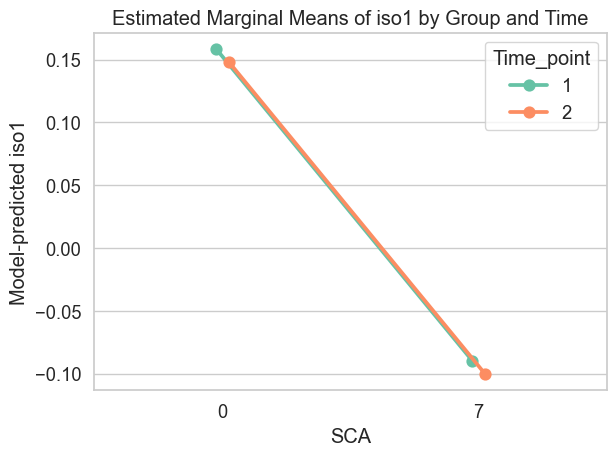

In [506]:
# Create a new dataframe with all combinations of SCA and Time_point
pred_df = df[["SCA", "Time_point"]].drop_duplicates().copy()
pred_df["Age_centered"] = 0  # mean-centered
pred_df["Age_onset_centered"] = 0
pred_df["C(side)"] = "Left"  # or use the reference level
pred_df["ori_subjName"] = df["ori_subjName"].iloc[0]  # dummy subject for predict()

# Predict means and CIs
pred_df["predicted"] = result.predict(pred_df)

# You can get CI by bootstrapping or approximating using standard error:
from statsmodels.stats.outliers_influence import summary_table

# We simulate fitted values and SE for plotting (simplified)
# Plot with seaborn
sns.pointplot(
    data=pred_df,
    x="SCA",
    y="predicted",
    hue="Time_point",
    dodge=True,
    capsize=0.1,
    errwidth=1,
    palette="Set2"
)
plt.ylabel("Model-predicted iso1")
plt.title("Estimated Marginal Means of iso1 by Group and Time")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_MerginalMean.png')

plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\2615131218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


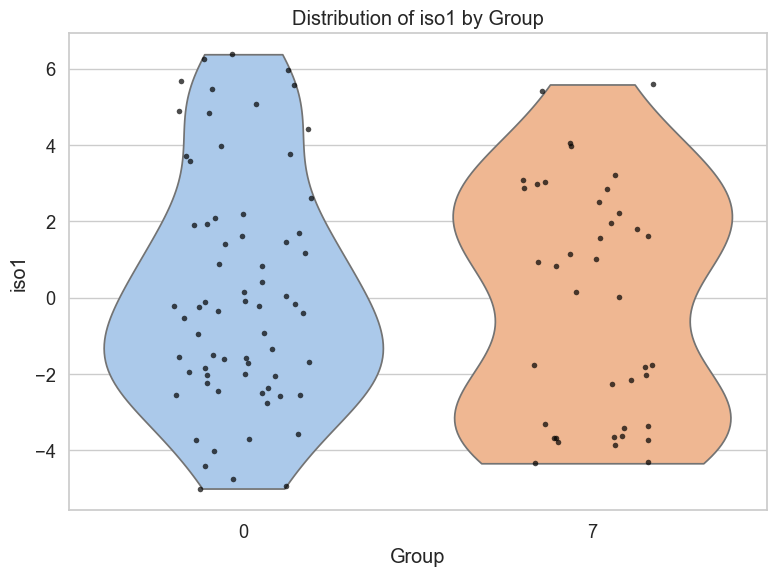

In [507]:

# Set a clean, publication-style aesthetic
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 6))

# Violin plot
sns.violinplot(
    x="SCA",             # group variable (e.g., 'SCA1', 'control')
    y="iso1",            # outcome variable
    data=df,
    inner=None,          # don't show default boxplot inside
    palette="pastel",
    cut=0                # trim to data range
)

# Overlay individual points
sns.stripplot(
    x="SCA",
    y="iso1",
    data=df,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7
)

plt.title("Distribution of iso1 by Group")
plt.xlabel("Group")
plt.ylabel("iso1")
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\556016383.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


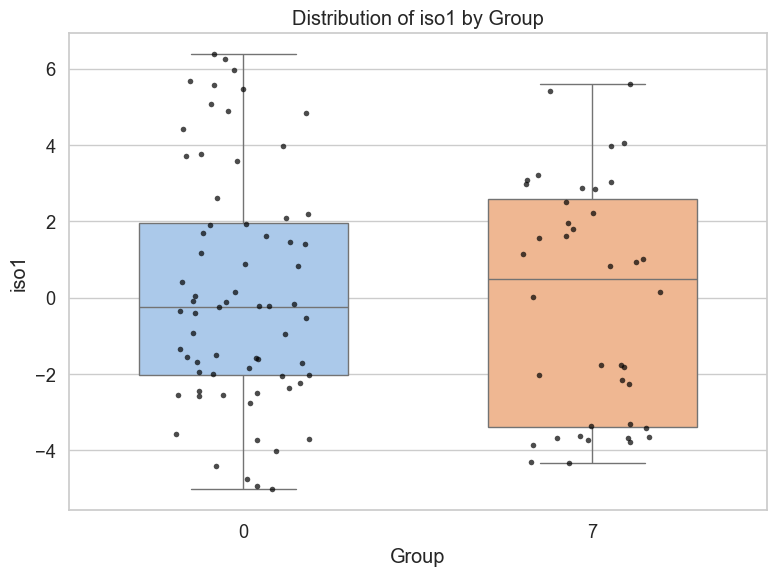

In [508]:
np.random.seed(42)  # fix the seed so there's no random jitter 

df = combined

# Set a clean, publication-style aesthetic
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="SCA",
    y="iso1",
    data=df,
    palette="pastel",
    width=0.6
)

# Overlay individual points
sns.stripplot(
    x="SCA",
    y="iso1",
    data=df,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7
)

plt.title("Distribution of iso1 by Group")
plt.xlabel("Group")
plt.ylabel("iso1")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_DistributionGroup.png')

plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\4213881479.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


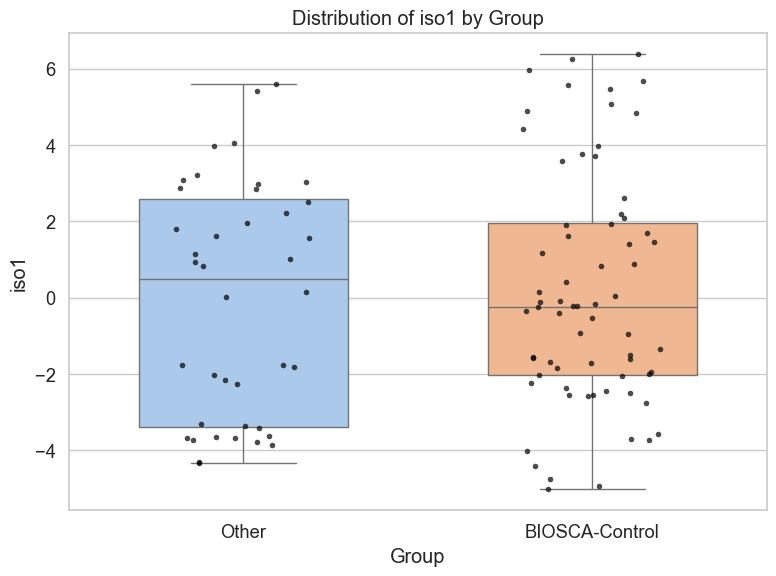

In [509]:
#######################  compare the controls from BIOSCA and CERMOI  #######################

np.random.seed(42) # fix the seed so there's no random jitter

df = combined.copy()

###########  standardize the iso1 by CodeICM  ############
df['iso1_zscore'] = df.groupby('CodeICM')['iso1'].transform(
    lambda x: (x - x.mean()) / x.std()
)


# Create a new group label column
def define_group(row):
    if row['SCA'] == 1:
        return 'SCA1'
    elif row['SCA'] == 0 and row['CodeICM'] == 'BIOSCA':
        return 'BIOSCA-Control'
    elif row['SCA'] == 0 and row['CodeICM'] == 'CERMOI':
        return 'CERMOI-Control'
    else:
        return 'Other'  # fallback if needed

df['Group'] = df.apply(define_group, axis=1)

# Plot
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Group",
    y="iso1",
    #y="iso1_zscore",    ## use Z-score
    data=df,
    palette="pastel",
    width=0.6
)

sns.stripplot(
    x="Group",
    y="iso1",
    #y="iso1_zscore",    ## use Z-score
    data=df,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7
)

plt.title("Distribution of iso1 by Group")
plt.xlabel("Group")
plt.ylabel("iso1")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_DistributionGroup.png')
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_DistributionGroup_Z.png')

plt.show()


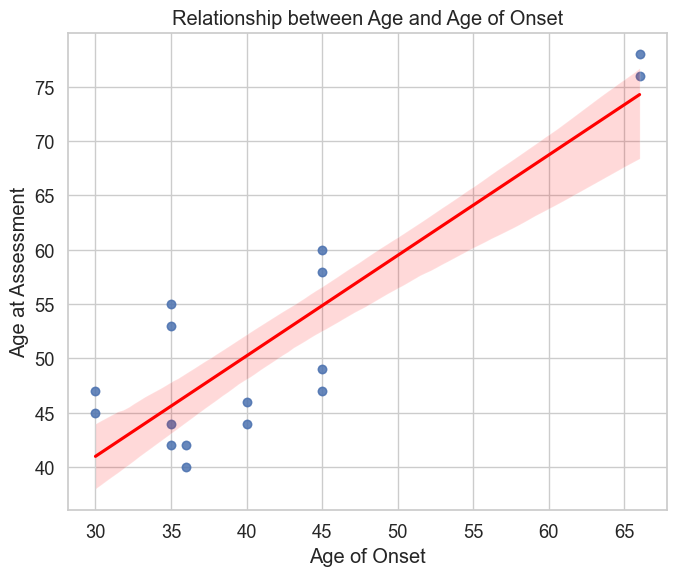

In [510]:
##################  Study the relationship between age and age_onset

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='Age', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('Age at Assessment')
plt.title('Relationship between Age and Age of Onset')
plt.tight_layout()
plt.show()


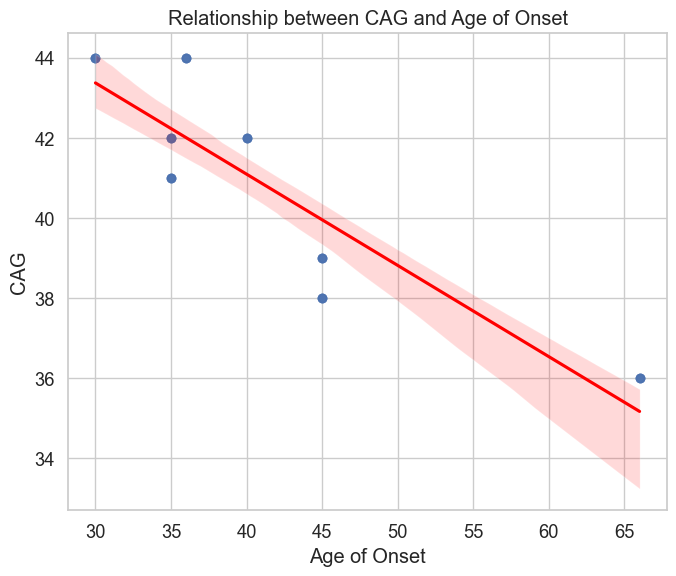

In [511]:
##################  Study the relationship between CAG and age_onset

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='CAG', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('CAG')
plt.title('Relationship between CAG and Age of Onset')
plt.tight_layout()
plt.show()


In [512]:
##############################  Plots studying the relationshio between isomap and CAG  ############################### 

In [560]:
df.columns

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [562]:
print(combined_CAG_only_SCA['CAG'].describe())

count    32.000000
mean     40.750000
std       2.723849
min      36.000000
25%      38.750000
50%      41.500000
75%      42.500000
max      44.000000
Name: CAG, dtype: float64


In [548]:
print(combined_CAG_only_SCA['side'].describe())

count     32
unique     2
top        L
freq      16
Name: side, dtype: object


In [564]:
##################  Finding the bins with roughly equal subjects in each  ###################

# Create 4 quantile-based bins for CAG
df['CAG_quantile_bin'] = pd.qcut(df['CAG'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Optional: check bin edges
bin_edges = pd.qcut(df['CAG'], q=4, retbins=True)[1]
print("Bin edges:", bin_edges)

# Optional: count number of subjects per bin
print(df['CAG_quantile_bin'].value_counts())

Bin edges: [36.   38.75 41.5  42.5  44.  ]
CAG_quantile_bin
Q1    8
Q2    8
Q3    8
Q4    8
Name: count, dtype: int64


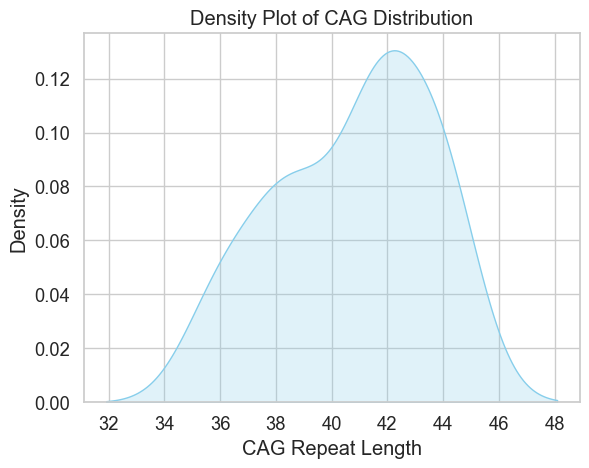

In [566]:
####################  Density plot of the CAG distribution  #####################

sns.kdeplot(data=df, x='CAG', fill=True, color='skyblue')
plt.xlabel('CAG Repeat Length')
plt.ylabel('Density')
plt.title('Density Plot of CAG Distribution')
plt.show()


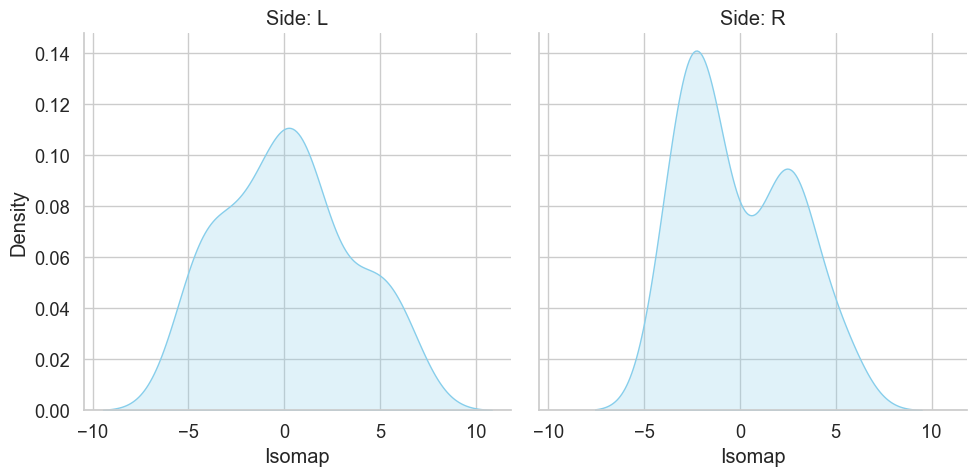

In [518]:
######################   Density plot of isomap for the two hemispheres  #######################

g = sns.FacetGrid(df, col="side", height=5, aspect=1)
g.map_dataframe(sns.kdeplot, x="iso1", fill=True, color='skyblue')
g.set_axis_labels("Isomap", "Density")
g.set_titles("Side: {col_name}")
plt.tight_layout()
plt.show()


In [519]:
###########################  Plotting Isomap values according to bins  ############################

df = combined_CAG_only_SCA
# Create CAG bins
#For equal numner of subjects: Bin edges: [40. 42. 45. 50. 62.]
#bins = [39,42,45,55,60,df['CAG'].max()]
#labels = ['39–42', '43–45', '46–55','56-60', f">{60}"]  

#bins = [39,42,45,50,55,df['CAG'].max()]
#labels = ['39–42', '43–45', '46–50','51-55', f">{55}"]  

bins = [39, 45, 50, 55, 60, df['CAG'].max()]  # adjust lower/upper edges if needed
labels = ['40–45', '46–50', '51–55', '56–60', f">{60}"]  # adjust final label as needed

#bins = [39, 50, 60, df['CAG'].max()]  # adjust lower/upper edges if needed
#labels = ['40–50', '51–60', f">{60}"]  # adjust final label as needed


# Create a new column for CAG range
df['CAG_range'] = pd.cut(df['CAG'], bins=bins, labels=labels, right=True, include_lowest=True)

# Plot boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='CAG_range', y='iso1', palette='Set2')
plt.xlabel('CAG Repeat Range')
plt.ylabel('Isomap Value')
plt.title('Isomap Value by CAG Repeat Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


ValueError: bins must increase monotonically.

In [520]:
###########################  Plotting Isomap values according to bins, L and R hemisphere  ############################

# Bin CAG values if not already done
bins = [39,42,45,55,60,df['CAG'].max()]
labels = ['39–42', '43–45', '46–55','56-60', f">{60}"]  

#bins = [39, 45, 50, 55, 60, df['CAG'].max()]
#labels = ['40–45', '46–50', '51–55', '56–60', f">{60}"]

#bins = [39, 50, 60, df['CAG'].max()]
#labels = ['40–50', '50-60', f">{60}"]
df['CAG_range'] = pd.cut(df['CAG'], bins=bins, labels=labels, right=True, include_lowest=True)

# Create FacetGrid: one plot per 'side'
g = sns.FacetGrid(df, col="side", height=5, aspect=1)
g.map_dataframe(sns.boxplot, x="CAG_range", y="iso1", palette="Set2", order=labels)
g.set_axis_labels("CAG Repeat Range", "Isomap Value")
g.set_titles("Side: {col_name}")
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()


ValueError: bins must increase monotonically.

C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\1928727901.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CAG_bin', y='isomap_resid', palette='Set2')


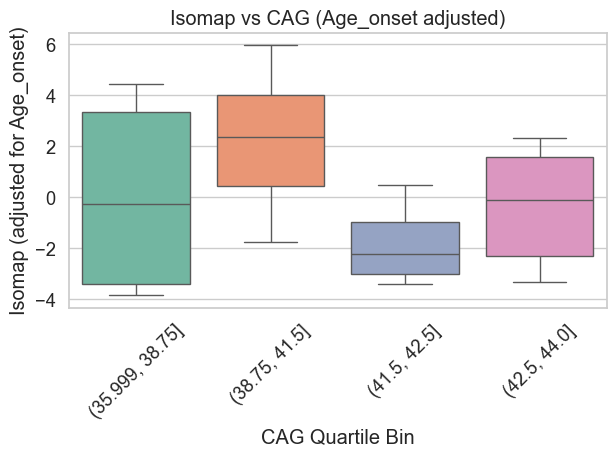

In [558]:
###################  Boxplots regressing out Age_onset  ###################

# Regress isomap ~ Age_onset
X = sm.add_constant(df['Age_onset'])
model = sm.OLS(df['iso1'], X).fit()
df['isomap_resid'] = model.resid  # residualized isomap

# Create quantile-based CAG bins (optional: or fixed bins if you prefer)
df['CAG_bin'] = pd.qcut(df['CAG'], q=4)

# Boxplot of residualized isomap
sns.boxplot(data=df, x='CAG_bin', y='isomap_resid', palette='Set2')
plt.xlabel('CAG Quartile Bin')
plt.ylabel('Isomap (adjusted for Age_onset)')
plt.title('Isomap vs CAG (Age_onset adjusted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\2950470033.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CAG_bin', y='isomap_resid', palette='Set2')


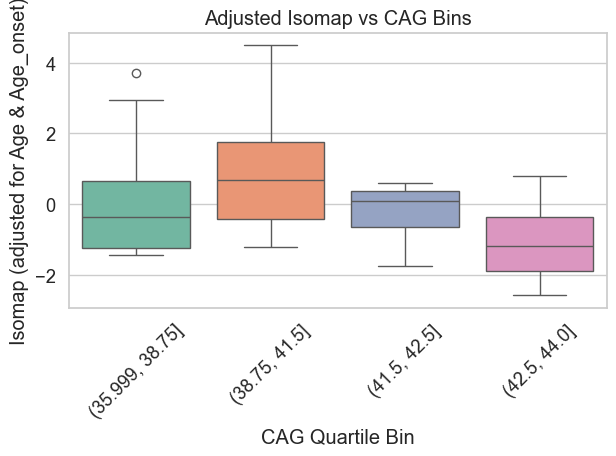

In [556]:
###################  Boxplots regressing out Age and Age_onset  ###################

# Define predictors and add constant
X = df[['Age', 'Age_onset']]
X = sm.add_constant(X)

# Fit linear model: isomap ~ Age + Age_onset
#model = sm.OLS(df['iso1'], X).fit()
model = sm.OLS(df['UMAP1_U2'], X).fit()
df['isomap_resid'] = model.resid  # residuals = isomap adjusted for Age and Age_onset

# Bin CAG into quartiles (or use custom bins)
df['CAG_bin'] = pd.qcut(df['CAG'], q=4)

# Plot residualized isomap vs binned CAG
sns.boxplot(data=df, x='CAG_bin', y='isomap_resid', palette='Set2')
plt.xlabel('CAG Quartile Bin')
plt.ylabel('Isomap (adjusted for Age & Age_onset)')
plt.title('Adjusted Isomap vs CAG Bins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_102528\2091976850.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


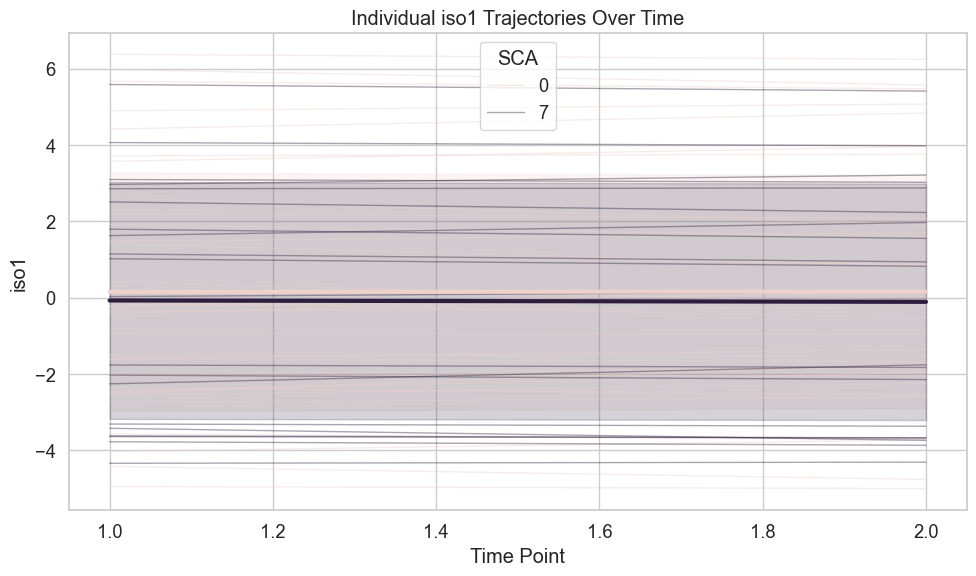

In [524]:
#######################  Visualizing the evolution of values among time_points  #########################

#df = combined_CAG_only_SCA
df = combined

# Example assumes your DataFrame is called df and includes:
# 'iso1' - the outcome variable
# 'Time_point' - time points (e.g., 1, 2, 3)
# 'ori_subjName' - subject ID
# 'SCA' - group (e.g., "SCA1" vs. "control")

plt.figure(figsize=(10, 6))

# Plot individual trajectories
sns.lineplot(
    data=df,
    x="Time_point",
    y="iso1",
    hue="SCA",
    units="ori_subjName",
    estimator=None,
    alpha=0.4,  # semi-transparent lines
    lw=1  # line width
)

# Optional: Add group-level smoothed trend lines
sns.lineplot(
    data=df,
    x="Time_point",
    y="iso1",
    hue="SCA",
    estimator="mean",
    ci="sd",
    lw=3,
    legend=False
)

plt.title("Individual iso1 Trajectories Over Time")
plt.xlabel("Time Point")
plt.ylabel("iso1")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_maxIso1_time1_2_Trajectory.png')

plt.show()


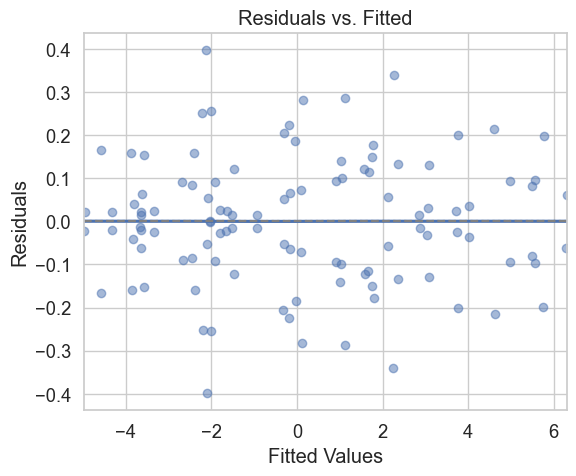

<Figure size 600x500 with 0 Axes>

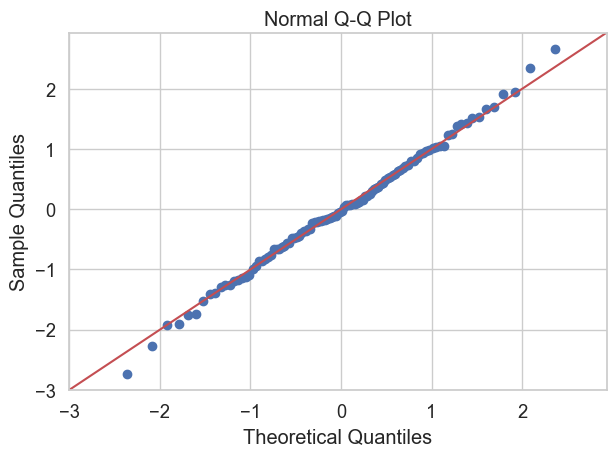

In [526]:
#######################  Residual versus fitted plots  #######################
########################     QQ-plots    ######################

df = combined

# Fit your LMM
model = smf.mixedlm("iso1 ~ SCA + Time_point", data=df, groups=df["ori_subjName"])
result = model.fit()

# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

# Plot 1: Residuals vs. Fitted
plt.figure(figsize=(6, 5))
sns.residplot(x=fitted, y=residuals, lowess=True, scatter_kws={'alpha': 0.5})
plt.axhline(0, color='gray', linestyle='--')  # ← fixed line
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_Residual.png')

plt.show()

# Plot 2: Q-Q Plot
plt.figure(figsize=(6, 5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_QQ.png')

plt.show()


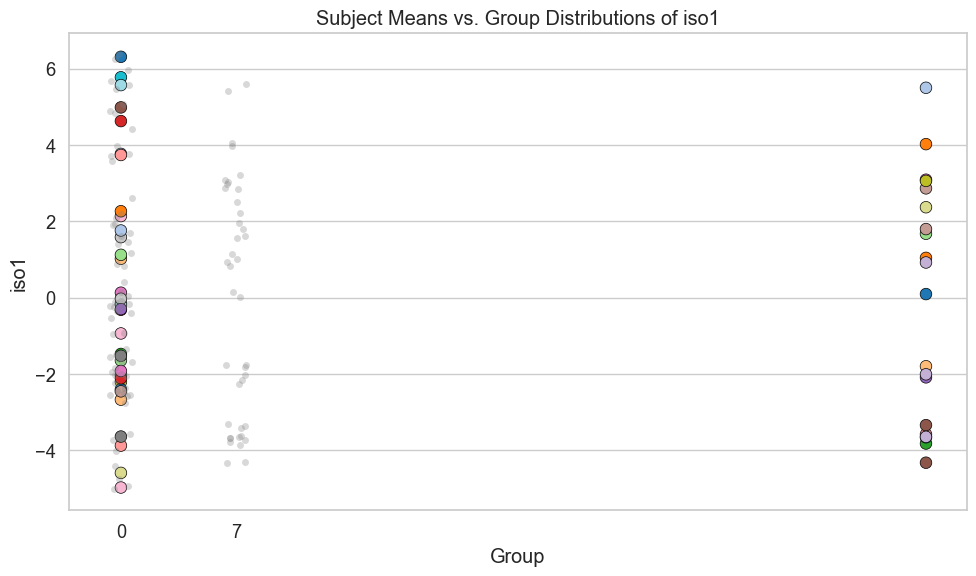

In [528]:
#######################   Comparison of group distributions  #######################

# 1. Compute subject-level means
subject_means = df.groupby(['ori_subjName', 'SCA'])['iso1'].mean().reset_index()
subject_means.columns = ['ori_subjName', 'SCA', 'iso1_subject_mean']

# 2. Merge subject means with original data
df_merged = df.merge(subject_means, on=['ori_subjName', 'SCA'])

# 3. Create plot
plt.figure(figsize=(10, 6))

# Stripplot of all individual data points (light gray)
sns.stripplot(x='SCA', y='iso1', data=df_merged, jitter=True, alpha=0.3, color='gray')

# Overlay subject means with scatterplot (colored by subject)
sns.scatterplot(x='SCA', y='iso1_subject_mean', data=subject_means, 
                hue='ori_subjName', palette='tab20', legend=False,
                s=70, edgecolor='black', linewidth=0.5)

plt.title('Subject Means vs. Group Distributions of iso1')
plt.ylabel('iso1')
plt.xlabel('Group')
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_InterclassCorrelation.png')

plt.show()


In [ ]:
#######################  Below specific LMM tests for association between shape other measures   ####################
#######################  Once some significance is found, come here for further investigation    ####################

In [538]:
###############################  Quick test of LMM  ###############################

df = combined_CAG_only_SCA

df['iso1_centered'] = df['iso1'] - df['iso1'].mean()
df['iso2_centered'] = df['iso2'] - df['iso2'].mean()       
df['iso3_centered'] = df['iso3'] - df['iso3'].mean()   
df['UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
df['UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
df['UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
df['UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
df['UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
df['UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
df['Age_centered'] = df['Age'] - df['Age'].mean()
df = df.dropna(subset=['Age_onset', 'Age', 'side'])

#measure = 'iso1_centered'
measure = 'UMAP1_U2_centered'

x_var = 'CAG_centered'          # DEFAULT
#x_var = 'CAG_centered*C(side)' # Estimating different slopes and intercepts for left and right hemispheres
                                # Testing whether, for example, CAG influences left and right hemispheres differently 
#x_var = 'Time_point'           # Testing if from one timePoint to another the shape changes
#x_var = 'Age_onset'            # Testing the effect of Age_onset on shape, can put CAG as covariate

covariates = 'Age_onset_centered + C(side)'  # DEFAULT
#covariates = 'C(side)'
#covariates = 'Age_onset_centered'                       # If moving side to x_var as interaction term
#covariates = 'Age_centered + Age_onset_centered + C(side)' 
#covariates = 'Age_onset_centered + C(side) + C(Sex)' 
#covariates = 'CAG + C(side) + C(Sex)'                   # If x_var is Age_onset, put CAG as covariate

model_lmm = smf.mixedlm(
    formula=f"{measure} ~ {x_var} + {covariates}",
    #formula=f"{measure} ~ {x_var}",    
    data=df,
    #re_formula="~Age")         # Optional: Random slope for Age
    #re_formula="~CAG")         # Optional: Random slope for CAG
    #re_formula="~Age_onset",         # Optional: Random slope for Age_onset
    groups=df['ori_subjName']
)
result = model_lmm.fit()
#print(result.summary())

#####################################################################################
# Extract summary as string and manually parse it
summary_str = result.summary().as_text()

# Print full summary if desired
print(summary_str)

# Or parse the coefficients into a DataFrame
# This grabs the coefficients table using .params and .bse
params = result.params
bse = result.bse
pvalues = result.pvalues
conf_int = result.conf_int()

# Build a DataFrame manually
summary_df = pd.DataFrame({
    "Coef.": params,
    "Std.Err.": bse,
    "P>|z|": pvalues,
    "CI_lower": conf_int[0],
    "CI_upper": conf_int[1]
})

# Format p-values to show more decimals
summary_df["P>|z|"] = summary_df["P>|z|"].apply(lambda p: f"{p:.8f}")

# Display nicely
print(summary_df)


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: UMAP1_U2_centered
No. Observations: 32      Method:             REML             
No. Groups:       16      Scale:              0.1363           
Min. group size:  2       Log-Likelihood:     -42.8774         
Max. group size:  2       Converged:          Yes              
Mean group size:  2.0                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.389    0.589  0.659 0.510 -0.767  1.544
C(side)[T.R]         -0.777    0.834 -0.933 0.351 -2.411  0.856
CAG_centered         -1.333    0.338 -3.946 0.000 -1.994 -0.671
Age_onset_centered   -0.295    0.087 -3.408 0.001 -0.465 -0.125
Group Var             2.712    4.066                           

                        Coef.   Std.Err.       P>|z|

In [552]:
#########################################   Likelihood ratio test  ###########################################
# comparing log-likelihoods of nested models, for small sample size and the testing of a key effect
# Use reml=False for both models. REML (restricted maximum likelihood) is good for estimating variance components
# but not for comparing models with different fixed effects.
# We're using a chi-square distribution with df=1 because you're testing 1 parameter (CAG_centered).   

from scipy.stats import chi2

# FULL MODEL: includes CAG_centered (your key effect)
model_full = smf.mixedlm(
    "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side) + C(Time_point)",
#    "iso1_centered ~ CAG_centered + Age_onset_centered + C(side) + C(Time_point)",
    data=df,
    groups=df["ori_subjName"]
)
result_full = model_full.fit(reml=False)  # Use ML (not REML) for model comparison

# REDUCED MODEL: same as above, but WITHOUT CAG_centered
model_reduced = smf.mixedlm(
    "UMAP1_U2_centered ~ Age_onset_centered + C(side) + C(Time_point)",
#    "iso1_centered ~ Age_onset_centered + C(side) + C(Time_point)",
    data=df,
    groups=df["ori_subjName"]
)
result_reduced = model_reduced.fit(reml=False)

# LRT statistic
lrt_stat = 2 * (result_full.llf - result_reduced.llf)

# df = number of parameters you removed (1 parameter = CAG_centered)
p_value = chi2.sf(lrt_stat, df=1)

# Print results
print(f"Likelihood Ratio Test statistic: {lrt_stat:.4f}")
print(f"p-value: {p_value:.4g}")

if p_value < 0.05:
    print(" CAG_centered significantly improves the model (reject null hypothesis).")
else:
    print(" No significant effect of CAG_centered.")


Likelihood Ratio Test statistic: 13.3100
p-value: 0.000264
 CAG_centered significantly improves the model (reject null hypothesis).


In [ ]:
###########  Calculating the ICC: intraclass correlation coefficients  ##########
# To understand what is the proportion of variability in random intercept
# Random intercept variance (subject) / (Random intercept variance (subject) + Residual variance (error))

import statsmodels.formula.api as smf

model_lmm = smf.mixedlm(
    formula="iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)",
    data=df,
    groups=df["ori_subjName"]
)

result = model_lmm.fit()

# Extract random intercept variance (subject-level variance)
subject_var = result.cov_re.iloc[0, 0]

# Extract residual (within-subject / error) variance
residual_var = result.scale

print(f"Random intercept variance (subject): {subject_var:.2f}")
print(f"Residual variance (error): {residual_var:.2f}")

icc = subject_var / (subject_var + residual_var)
print(f"Intraclass Correlation Coefficient (ICC): {icc:.3f}")


In [ ]:
print(df["iso1_centered"].describe())

In [ ]:
###################################   Some hemisphere-specific investigations  ####################################

In [ ]:
##################  Compare models with and without interaction term  ###################
################## Split the data into left and right hemisphere subsets and run separate models  ###################
##################  Note that this count as multiple testing, correction needed  ####################
def test_LMM(df):
    df['iso1_centered'] = df['iso1'] - df['iso1'].mean()
    df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df['Age_centered'] = df['Age'] - df['Age'].mean()
    df = df.dropna(subset=['Age_onset', 'Age', 'side'])

    measure = 'iso1_centered'
    x_var = 'CAG_centered'          # DEFAULT
    covariates = 'Age_onset_centered + C(side)'  # DEFAULT 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

def test_LMM_interaction_side(df):
    df['iso1_centered'] = df['iso1'] - df['iso1'].mean()
    df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df['Age_centered'] = df['Age'] - df['Age'].mean()
    df = df.dropna(subset=['Age_onset', 'Age', 'side'])

    measure = 'iso1_centered'
    x_var = 'CAG_centered*C(side)'           # Estimating different slopes and intercepts for left and right hemispheres
                                             # Testing whether, for example, CAG influences left and right hemispheres differently 
    covariates = 'Age_onset_centered'        # If moving side to x_var as interaction term

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

####################################################################################################
df = combined_CAG_only_SCA
df_L = df[df['side'] == 'L']
df_R = df[df['side'] == 'R']
test_LMM(df)
print('__________________Interaction side____________________')
print()
test_LMM_interaction_side(df)
print('__________________Left hemisphere____________________')
print()
test_LMM(df_L)
print('__________________Right hemisphere___________________')
print()
test_LMM(df_R)

In [ ]:
#### Is the hemispheric difference in shape different depending on SCA type? ####

import statsmodels.formula.api as smf
df = combined
df['iso1_centered'] = df['iso1'] - df['iso1'].mean()
df['Age_centered'] = df['Age'] - df['Age'].mean()

model = smf.mixedlm(
#    formula="iso1_centered ~ C(side) * C(SCA) + Age_centered + Sex",   # centered or not, same p-val
    formula="iso1 ~ C(side) * C(SCA) + Age + Sex",    
    data=df,
    groups=df['ori_subjName']
)
result = model.fit()
print(result.summary())


In [ ]:
################################  Study of other factors for LMM modeling  #################################

In [ ]:
# LMM, Statistically test for group differences: sex and hemisphere

df = combined
model = smf.mixedlm(
    "iso1 ~ C(Sex) + C(side)", 
    data=df, 
    groups=df["ori_subjName"]
)
result = model.fit()
print(result.summary())


In [ ]:
##########################################    Plots    ###########################################

In [ ]:
##################################  The LMM results for further plotting  ###############################
################  Adding the random slope for calculation of the randim slope variance  #################

def test_LMM(df):
    df['iso1_centered'] = df['iso1'] - df['iso1'].mean()
    df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df['Age_centered'] = df['Age'] - df['Age'].mean()
    df = df.dropna(subset=['Age_onset', 'Age', 'side'])

    measure = 'iso1_centered'
    x_var = 'CAG_centered'          # DEFAULT
    covariates = 'Age_onset_centered + C(side)'  # DEFAULT 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName'],
        re_formula="~CAG_centered"  ######### !!! adding a random slope for comparison 
    )
    result = model_lmm.fit()
    return result

####################################################################################################
df = combined_CAG_only_SCA
result = test_LMM(df)
print(result.summary())

print(result.cov_re)
slope_variance = result.cov_re.loc['CAG_centered', 'CAG_centered']
print("Random slope variance:", slope_variance)

slope_variance = result_lmm.cov_re.loc['CAG_centered', 'CAG_centered']
print("Random slope variance:", slope_variance)


In [ ]:
###################   Testing LRT to decide to include the random slope or not  ###################

# Define the formula explicitly
formula = "iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)"

# Model 1: Random intercept only
model_reduced = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"]
)
result_reduced = model_reduced.fit()

# Model 2: Random intercept + random slope for CAG_centered
model_full = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"],
    re_formula="~CAG_centered"
)
result_full = model_full.fit()

# Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)
p_value = stats.chi2.sf(lr_stat, df=1)
print("Likelihood Ratio Test statistic:", lr_stat)
print("p-value:", p_value)


In [ ]:
###########################  residual plot, based on the result of the LMM in the cell above  ###########################
# Create a new DataFrame with values for CAG_centered
###  Rerun the aboce cell when needed!!!!!!!!  ###

pred_df = pd.DataFrame()
pred_df["CAG_centered"] = np.linspace(df["CAG_centered"].min(), df["CAG_centered"].max(), 100)

# Set other covariates to their mean or mode (you can change this logic)
pred_df["Age_centered"] = df["Age_centered"].mean()
pred_df["Age_onset_centered"] = df["Age_onset_centered"].mean()
pred_df["side"] = df["side"].mode()[0]  # most common side
pred_df["ori_subjName"] = df["ori_subjName"].iloc[0]  # just pick any group for prediction

# Predict from your model
pred_df["predicted"] = result.predict(pred_df)

df["fitted"] = result.fittedvalues
df["residuals"] = result.resid

# Partial residual: add back the effect of CAG only
df["partial_CAG"] = df["residuals"] + result.params["CAG_centered"] * df["CAG_centered"]

sns.scatterplot(data=df, x="CAG_centered", y="partial_CAG")
sns.lineplot(x=pred_df["CAG_centered"], y=pred_df["predicted"], color="red")
plt.title("Partial Effect of CAG on isomap (adjusted for other covariates)")

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_pertialEffect_CAG.png')

plt.show()


In [ ]:
###########################  probplot plot, based on the result of the LMM in the cell above   ###########################
import scipy.stats as stats

# Extract residuals from the model
residuals = result.resid

# Q-Q plot
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (LMM)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
###########################  QQ plot, based on the result of the LMM in the cell above   ###########################
plt.figure(figsize=(6, 5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_QQ.png')

plt.show()

In [ ]:
##################  Normality test  ####################
# if p > 0.05, not normal
from scipy.stats import shapiro
shapiro_stat, p_value = shapiro(result.resid)
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

In [ ]:
##################  plot of random effect  ##################
random_effects = result.random_effects
sns.boxplot(data=pd.DataFrame(random_effects).T)
plt.title("Random Effects: Variability Across Subjects")


In [ ]:
###  to quantify the range in the plot above  ###
#re_flat.describe()

In [ ]:
##################  plot of random effect  ##################
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract and convert random effects into a DataFrame
random_effects = result.random_effects

# Each entry is a subject: random intercept (usually one value)
# We'll flatten this into a DataFrame
re_df = pd.DataFrame.from_dict(random_effects, orient='index')

# Rename column for clarity
re_df.columns = ['Random_Intercept']

# Plot the random intercepts across subjects
plt.figure(figsize=(10, 4))
sns.boxplot(data=re_df, y='Random_Intercept')
plt.title("Random Intercepts Across Subjects")
plt.ylabel("Intercept Value")
plt.xlabel("Subjects (summarized)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#################  model random intercept and random slope  ###################

model_lmm = smf.mixedlm(
    formula="iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)",
    data=df,
    groups=df["ori_subjName"],
    re_formula="~CAG_centered"  # random intercept + slope for CAG_centered
)
result_lmm = model_lmm.fit()

##################  plot of random effect  ##################
result_lmm.random_effects

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
print(re_df.head())

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df.columns = ['Random_Intercept', 'Random_Slope']

re_df = re_df.reset_index().melt(id_vars='index', var_name='Effect', value_name='Value')
sns.boxplot(data=re_df, x='Effect', y='Value')
plt.title("Random Effects (Intercept & Slope)")
plt.xlabel("Random Effect Type")
plt.ylabel("Estimate")
plt.grid(True)
plt.show()

In [ ]:
#############################  model fit plot, fixed plus random effect  #############################

import seaborn as sns
import matplotlib.pyplot as plt

# Predict values from the full mixed effects model (includes random effects)
df["predicted_iso1"] = result.predict(df)

# Scatter actual data
sns.scatterplot(data=df, x="CAG_centered", y="iso1_centered", label="Actual data")

# Add subject-level fitted line
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="predicted_iso1", color="red", label="LMM prediction")

plt.title("Predicted vs Actual iso1 (LMM, includes subject random effects)")
plt.xlabel("CAG (centered)")
plt.ylabel("iso1 (centered)")
plt.legend()
plt.show()


In [ ]:
###########  model fit with and without random effects  #############

ols_result = smf.ols("iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)", data=df).fit()
df["ols_pred"] = ols_result.predict(df)

sns.lineplot(x="CAG_centered", y="ols_pred", data=df.sort_values("CAG_centered"), color="green", label="OLS fixed-effect prediction")

df["fixed_pred"] = (
    result.params["Intercept"]
    + result.params["CAG_centered"] * df["CAG_centered"]
    + result.params["Age_centered"] * df["Age_centered"]
    + result.params["Age_onset_centered"] * df["Age_onset_centered"]
    + df["side"].map(lambda s: result.params.get(f"C(side)[T.{s}]", 0))  # for side levels
)

sns.lineplot(x="CAG_centered", y="fixed_pred", data=df.sort_values("CAG_centered"), color="blue", label="Fixed effects only")


In [ ]:
###########  model fit without random effects  #############

import statsmodels.formula.api as smf

# Fit a simple OLS model (no random effects)
lm_result = smf.ols("iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)", data=df).fit()

# Predict values
df["ols_pred"] = lm_result.predict(df)

# Plot
sns.scatterplot(data=df, x="CAG_centered", y="iso1_centered", label="Actual data")
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="ols_pred", color="green", label="OLS prediction")

plt.title("Prediction from Simple Linear Model (Fixed Effects Only)")
plt.xlabel("CAG (centered)")
plt.ylabel("iso1 (centered)")
plt.legend()
plt.show()


In [ ]:
print(combined_CAG_only_SCA['Time_point'].value_counts())

combined_CAG_only_SCA_t1 = combined_CAG_only_SCA[combined_CAG_only_SCA['Time_point'] == 1]

curMeasure = 'iso1'
curCorVal = 'CAG'        
partialCorCol = ['Age', 'Age_onset','side']            # if SCA1, SCA3
partialCorParam =  'Age + Age_onset + side'              # if SCA1, SCA3

# Define mapping of curCorVal to DataFrame
data_map = {
    'INAS': combined_INAS_only_SCA,
    'CAG': combined_CAG_only_SCA_t1,    
    'CCFS': combined_CCFS_only_SCA,
    'SARA': combined_only_SCA
}
curData = data_map.get(curCorVal, None)
# Optional: Raise an error or provide a message if curCorVal is invalid
if curData is None:
    print(f"Warning: No data found for curCorVal = '{curCorVal}'")
    
# Prepare the data
df = curData[[curMeasure, curCorVal] + partialCorCol] # Ensure required columns are present

################  negate the slope, optional  ################
# for matching visual direction with another figure if needed
df[curCorVal] = -df[curCorVal]
##############################################################

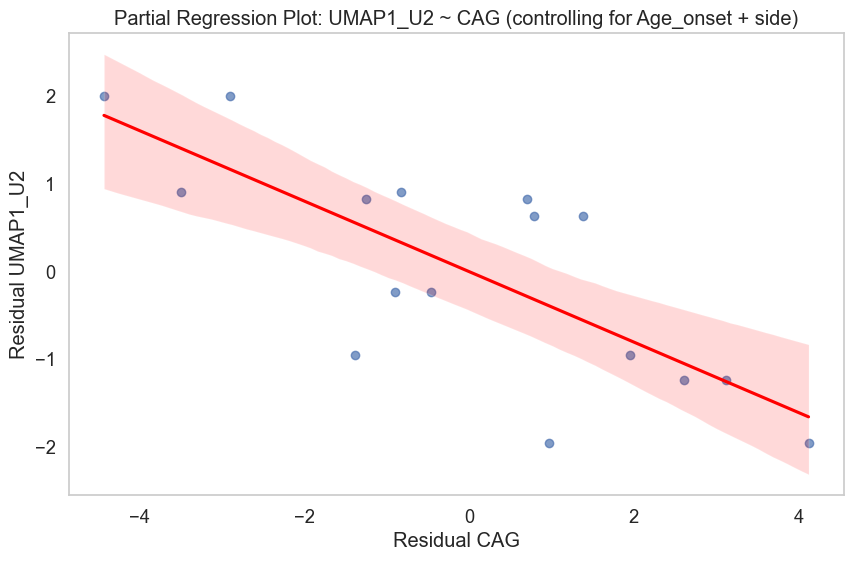

In [576]:
##############################  Plot with partial correlation  ##############################
#########################   Plotting taking into account the residuals   ##########################
# Use linear regression with Pearson's coef between residuals

combined_CAG_only_SCA_t1 = combined_CAG_only_SCA[combined_CAG_only_SCA['Time_point'] == 1]

curMeasure = 'UMAP1_U2'
curCorVal = 'CAG'
#partialCorCol = ['Age', 'Sex','side']            
#partialCorParam =  'Age + Sex + side'  
partialCorCol = ['Age_onset','side']            # if SCA1, SCA3
partialCorParam =  'Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Age_onset','side']            # if SCA1, SCA3
#partialCorParam =  'Age + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','Disease_duration']            # if SCA1, SCA3
#partialCorParam =  'Age + Sex + Age_onset + side + Disease_duration'              # if SCA1, SCA3
#partialCorCol = ['Age', 'Sex', 'Age_onset','side','CodeICM']  # if SCA2, SCA7
#partialCorParam =  'Age + Sex + Age_onset + side + CodeICM'    # if SCA2, SCA7

# Define mapping of curCorVal to DataFrame
data_map = {
    'INAS': combined_INAS_only_SCA,
    #'CAG': combined_CAG_only_SCA,     #!!!!!!!!!!!!!!!!!!! if plot all time points !!!!!!!!!!!!!!!!!!!!!
    'CAG': combined_CAG_only_SCA_t1,   #!!!!!!!!!!!!!!!!!!!   if plot time 1 only  !!!!!!!!!!!!!!!!!!!!!!
    'CCFS': combined_CCFS_only_SCA,
    'SARA': combined_only_SCA
}
curData = data_map.get(curCorVal, None)
# Optional: Raise an error or provide a message if curCorVal is invalid
if curData is None:
    print(f"Warning: No data found for curCorVal = '{curCorVal}'")
    
# Prepare the data
df = curData[[curMeasure, curCorVal] + partialCorCol] # Ensure required columns are present

################  negate the slope, optional  ################
# for matching visual direction with another figure if needed
df[curCorVal] = -df[curCorVal]
##############################################################

# Fit the OLS model using smf.ols with missing='drop'
model = smf.ols(formula=curMeasure+' ~ '+ curCorVal +' + ' + partialCorParam, data=df, missing='drop').fit()

# Partial regression: calculate residuals
residual_x = smf.ols(formula=curMeasure+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
# Residual of curCorVal regressed
residual_y = smf.ols(formula=curCorVal+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
raw_y = df[curCorVal]

# Align indices to ensure lengths match
residual_x, raw_y = residual_x.align(raw_y, join='inner')

## Plot the residuals
plt.figure(figsize=(10, 6))

# if plotting together with the shape spread of isomap
sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) # plot y raw CAG

# if emphasize effect of CAG on shape
#sns.regplot(x=residual_y, y=residual_x, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 

plt.ylabel('Residual '+curMeasure)      # plot x_CAG, y_shape
plt.xlabel('Residual '+curCorVal) 

# if emphasize effect of shape on CAG
#sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
#plt.ylabel('Residual '+curCorVal)      # plot x_shape, y_CAG
#plt.xlabel('Residual '+curMeasure) 

plt.title('Partial Regression Plot: '+curMeasure+' ~ '+curCorVal+' (controlling for '+partialCorParam+')')
plt.grid()


#############################################################################################
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA7\cor_SCA7_ctl_minU12_CAG_time1_2_ageOnsetSide_neg_Time1.png')

plt.show()

In [ ]:
###########################   WIP   ##########################
#To find the best model, compare AIC/BIC (lower is better).
#If the interaction model has lower AIC, keep the interaction terms.
#If the random slope model is better, keep varying Age effects.
#If neither improves AIC, keep the simpler model.
#print(df.isna().sum())  # Check missing values
#print(np.isinf(df).sum())  # Check infinite values

#print(f"Original Model AIC: {result.aic}")
#print(f"Original Model BIC: {result.bic}")
#print(f"Interaction Model AIC: {model_interaction.aic}")
#print(f"Random Slope Model AIC: {model_random_slope.aic}")



In [ ]:
#pip install pymer4 # run once

In [ ]:
#from pymer4.models import Lmer

In [ ]:
#  testing pymer4
"""
df = combined_CAG_only_SCA
df = df.copy()  # optional, just to be safe

# You may want to remove missing data
df = df.dropna(subset=[
    'iso1_centered', 'CAG_centered', 'Age_centered', 
    'Age_onset_centered', 'side', 'ori_subjName'
])

"""